In [1]:
import pandas as pd
import numpy as np

In [52]:
XLU_options_data = pd.read_hdf("data/etf_options_data.hf5", key="XLU").set_index("date")
XLU_options_data['exdate'] = pd.to_datetime(XLU_options_data['exdate'])
XLU_options_data.index = pd.to_datetime(XLU_options_data.index)

XLU_price_data = pd.read_hdf("data/etf_series.hf5", key="XLU").drop_duplicates()
XLU_price_series = XLU_price_data["Close"]

treasury_bill_3m = pd.read_csv("C:\\Users\\asus\Downloads\\DTB3.csv").set_index("DATE")
treasury_bill_3m.index = pd.to_datetime(treasury_bill_3m.index)

XLU_options_data_filtered = XLU_options_data[XLU_options_data.index.isin(XLU_price_series.index)]
XLU_options_data_filtered['price'] = XLU_price_series

XLU_options_data_filtered["strike_price"] = XLU_options_data_filtered["strike_price"] / 1000
XLU_options_data_filtered["risk-free interest rate %"] = treasury_bill_3m["DTB3"]
XLU_options_data_filtered["risk-free interest rate %"] = pd.to_numeric(XLU_options_data_filtered["risk-free interest rate %"], errors='coerce')
XLU_options_data_filtered["days to expiry"] = (XLU_options_data_filtered["exdate"] - XLU_options_data_filtered.index).dt.days
XLU_options_data_filtered = XLU_options_data_filtered[XLU_options_data_filtered["days to expiry"] != 0] # remove options expiring that day
XLU_options_data_filtered["impl_volatility"].fillna(method='ffill', inplace=True) # forward fill when sigma=0
XLU_options_data_filtered["risk-free interest rate %"].fillna(method='ffill', inplace=True) # forward fill when t-bill yield unknown
XLU_options_data_filtered["strike minus price"] = np.abs(XLU_options_data_filtered["strike_price"] - XLU_options_data_filtered["price"])

XLU_options_data_filtered

date_index = XLU_options_data_filtered.index.unique()
filtered_data = pd.DataFrame()
for date in date_index:
    options_on_date = XLU_options_data_filtered.loc[date]
    no_of_ex_dates = options_on_date["exdate"].nunique()
    if no_of_ex_dates > 1:
        options_on_date = options_on_date.query("exdate == exdate.min()")
    closest_strike = options_on_date[options_on_date["strike minus price"] == options_on_date["strike minus price"].min()]
    if len(closest_strike) > 2:
        c_closest_strike = closest_strike[closest_strike["cp_flag"] == "C"]
        c_closest_strike = c_closest_strike[c_closest_strike["open_interest"] == c_closest_strike["open_interest"].max()]
        p_closest_strike = closest_strike[closest_strike["cp_flag"] == "P"]
        p_closest_strike = p_closest_strike[p_closest_strike["open_interest"] == p_closest_strike["open_interest"].max()]        
        closest_strike = pd.concat([c_closest_strike, p_closest_strike])        
    filtered_data = pd.concat([filtered_data, closest_strike])

filtered_data


C:\Users\asus\AppData\Local\Temp\ipykernel_2816\406699710.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  XLU_options_data_filtered["impl_volatility"].fillna(method='ffill', inplace=True) # forward fill when sigma=0
C:\Users\asus\AppData\Local\Temp\ipykernel_2816\406699710.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  XLU_options_data_filtered["impl_volatility"].fillna(method='ffill', inplace=True) # forward fill when sigma=0
C

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,price,risk-free interest rate %,days to expiry,strike minus price
date,,,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,27.578125,5.24,12,0.421875
2000-01-10,XLU,2000-01-22,P,28.0,0.5625,0.6875,0.0,0.188172,-0.664666,0.386708,-5.169018,1.818026,0.0,27.578125,5.24,12,0.421875
2000-01-11,XLU,2000-01-22,C,27.0,0.3750,0.5000,0.0,0.127058,0.711879,0.566956,-4.493506,1.616731,0.0,27.281250,5.27,11,0.281250
2000-01-11,XLU,2000-01-22,P,27.0,0.1250,0.2500,0.0,0.172316,-0.341669,0.455633,-4.489918,1.735216,0.0,27.281250,5.27,11,0.281250
2000-01-12,XLU,2000-01-22,C,27.0,0.2500,0.3750,0.0,0.163258,0.528509,0.545191,-6.095431,1.778476,0.0,27.000000,5.29,10,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-29,XLU,2023-09-01,P,64.0,0.3900,0.4400,74.0,0.152796,-0.551931,0.452776,-19.768590,2.285877,1414.0,63.860001,5.33,3,0.139999
2023-08-30,XLU,2023-09-01,C,63.5,0.3200,0.3600,802.0,0.156831,0.549472,0.536260,-28.384800,1.862935,766.0,63.570000,5.32,2,0.070000
2023-08-30,XLU,2023-09-01,P,63.5,0.2400,0.2800,837.0,0.160367,-0.453414,0.528108,-25.984860,1.863352,31.0,63.570000,5.32,2,0.070000


In [53]:
from scipy.stats import norm
from math import log, sqrt, exp

def Black76LognormalCall(S, K, r, sigma, T):
    if T <= 0 or S <= 0 or K <= 0 or sigma < 0:
        return float('nan')
    
    # Avoid numerical issues with very small T or sigma
    T = max(T, 1e-8)
    sigma = max(sigma, 1e-8)
    
    d1 = (log(S/K)+(r+sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    
    call_price = S*norm.cdf(d1) - K*exp(-r*T)*norm.cdf(d2)
    return call_price

def Black76LognormalPut(S, K, r, sigma, T):
    if T <= 0 or S <= 0 or K <= 0 or sigma < 0:
        return float('nan')
    
    # Avoid numerical issues with very small T or sigma
    T = max(T, 1e-8)
    sigma = max(sigma, 1e-8)
    
    d1 = (log(S/K)+(r+sigma**2/2)*T) / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    
    put_price = K*exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    return put_price

In [54]:
filtered_data['option_price'] = filtered_data.apply(
    lambda row: Black76LognormalCall(row['price'], 
                                      row['strike_price'], 
                                      row['risk-free interest rate %'] / 100, 
                                      row['impl_volatility'], 
                                      row['days to expiry'] / 365) if row['cp_flag'] == 'C' 
                else Black76LognormalPut(row['price'], 
                                         row['strike_price'], 
                                         row['risk-free interest rate %'] / 100, 
                                         row['impl_volatility'], 
                                         row['days to expiry'] / 365),
    axis=1
)

filtered_data


,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,price,risk-free interest rate %,days to expiry,strike minus price,option_price
date,,,,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,27.578125,5.24,12,0.421875,0.138993
2000-01-10,XLU,2000-01-22,P,28.0,0.5625,0.6875,0.0,0.188172,-0.664666,0.386708,-5.169018,1.818026,0.0,27.578125,5.24,12,0.421875,0.593770
2000-01-11,XLU,2000-01-22,C,27.0,0.3750,0.5000,0.0,0.127058,0.711879,0.566956,-4.493506,1.616731,0.0,27.281250,5.27,11,0.281250,0.434875
2000-01-11,XLU,2000-01-22,P,27.0,0.1250,0.2500,0.0,0.172316,-0.341669,0.455633,-4.489918,1.735216,0.0,27.281250,5.27,11,0.281250,0.187066
2000-01-12,XLU,2000-01-22,C,27.0,0.2500,0.3750,0.0,0.163258,0.528509,0.545191,-6.095431,1.778476,0.0,27.000000,5.29,10,0.000000,0.310823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-29,XLU,2023-09-01,P,64.0,0.3900,0.4400,74.0,0.152796,-0.551931,0.452776,-19.768590,2.285877,1414.0,63.860001,5.33,3,0.139999,0.412022
2023-08-30,XLU,2023-09-01,C,63.5,0.3200,0.3600,802.0,0.156831,0.549472,0.536260,-28.384800,1.862935,766.0,63.570000,5.32,2,0.070000,0.340580
2023-08-30,XLU,2023-09-01,P,63.5,0.2400,0.2800,837.0,0.160367,-0.453414,0.528108,-25.984860,1.863352,31.0,63.570000,5.32,2,0.070000,0.258659


In [55]:
from scipy.optimize import brentq

def impliedVolatility(S, K, r, price, T, cp_flag):
    # Select the appropriate Black-76 function based on cp_flag
    if cp_flag == "C":
        f_a = price - Black76LognormalCall(S, K, r, 1e-6, T)
        f_b = price - Black76LognormalCall(S, K, r, 5, T)
        option_price_func = lambda x: price - Black76LognormalCall(S, K, r, x, T)
    elif cp_flag == "P":
        f_a = price - Black76LognormalPut(S, K, r, 1e-6, T)
        f_b = price - Black76LognormalPut(S, K, r, 5, T)
        option_price_func = lambda x: price - Black76LognormalPut(S, K, r, x, T)
    else:
        raise ValueError("Invalid cp_flag. Use 'C' for call or 'P' for put.")

    # Check if a valid implied volatility exists
    if f_a * f_b > 0:
        return float('nan')  # Or handle as appropriate

    # Use brentq to find implied volatility
    impliedVol = brentq(option_price_func, 1e-6, 5)
    
    return impliedVol

In [56]:
filtered_data['implied volatility'] = filtered_data.apply(
    lambda row: impliedVolatility(
        row['price'], 
        row['strike_price'], 
        row['risk-free interest rate %'] / 100, 
        row['option_price'], 
        row['days to expiry'] / 365, 
        row['cp_flag']), axis=1)

filtered_data

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,price,risk-free interest rate %,days to expiry,strike minus price,option_price,implied volatility
date,,,,,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,27.578125,5.24,12,0.421875,0.138993,0.143454
2000-01-10,XLU,2000-01-22,P,28.0,0.5625,0.6875,0.0,0.188172,-0.664666,0.386708,-5.169018,1.818026,0.0,27.578125,5.24,12,0.421875,0.593770,0.188172
2000-01-11,XLU,2000-01-22,C,27.0,0.3750,0.5000,0.0,0.127058,0.711879,0.566956,-4.493506,1.616731,0.0,27.281250,5.27,11,0.281250,0.434875,0.127058
2000-01-11,XLU,2000-01-22,P,27.0,0.1250,0.2500,0.0,0.172316,-0.341669,0.455633,-4.489918,1.735216,0.0,27.281250,5.27,11,0.281250,0.187066,0.172316
2000-01-12,XLU,2000-01-22,C,27.0,0.2500,0.3750,0.0,0.163258,0.528509,0.545191,-6.095431,1.778476,0.0,27.000000,5.29,10,0.000000,0.310823,0.163258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-29,XLU,2023-09-01,P,64.0,0.3900,0.4400,74.0,0.152796,-0.551931,0.452776,-19.768590,2.285877,1414.0,63.860001,5.33,3,0.139999,0.412022,0.152796
2023-08-30,XLU,2023-09-01,C,63.5,0.3200,0.3600,802.0,0.156831,0.549472,0.536260,-28.384800,1.862935,766.0,63.570000,5.32,2,0.070000,0.340580,0.156831
2023-08-30,XLU,2023-09-01,P,63.5,0.2400,0.2800,837.0,0.160367,-0.453414,0.528108,-25.984860,1.863352,31.0,63.570000,5.32,2,0.070000,0.258659,0.160367


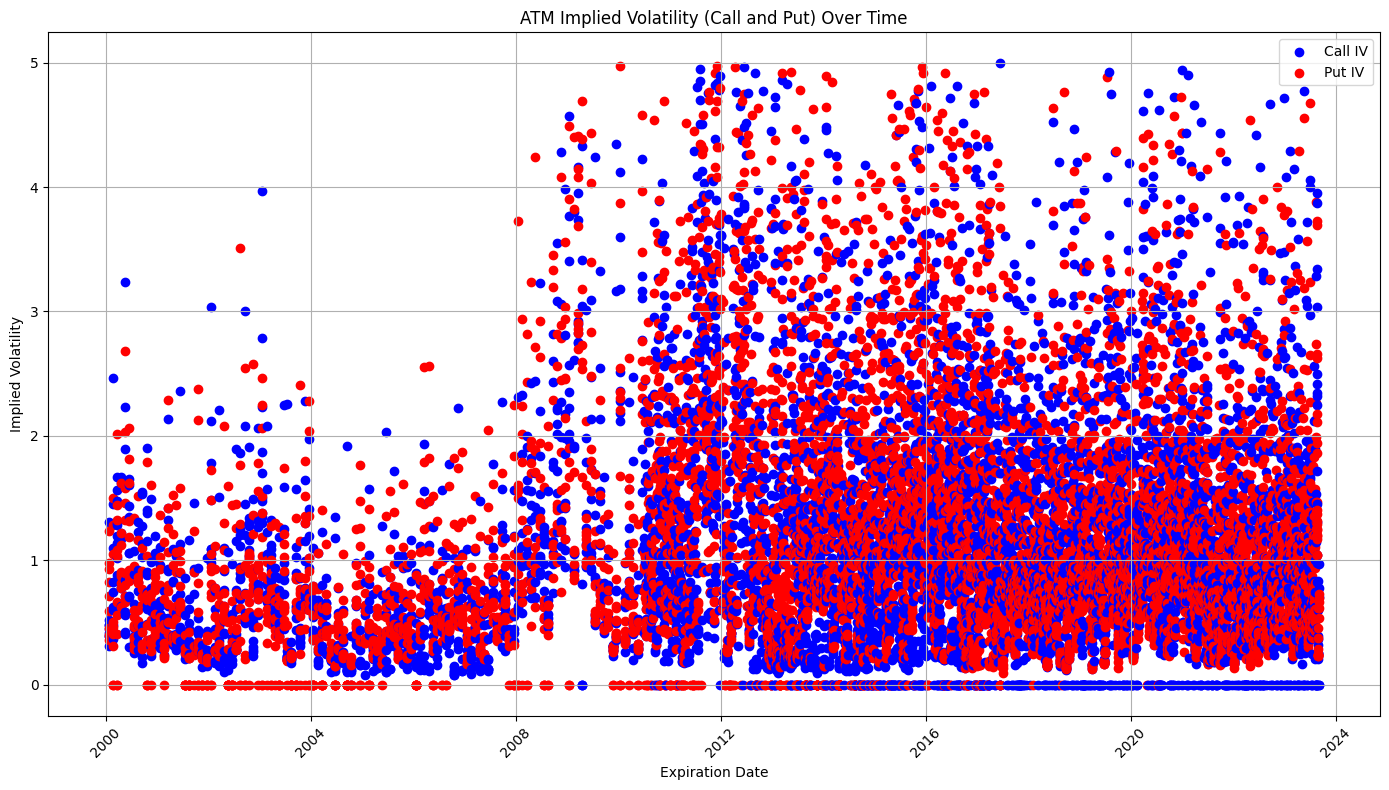

In [37]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(14, 8))

# Step 1: Loop through each unique date
unique_dates = XLF_options_data_filtered1['exdate'].unique()

for expiration in unique_dates:
    # Filter data for the specific expiration date
    daily_data = XLF_options_data_filtered1[XLF_options_data_filtered1['exdate'] == expiration].copy()  # Make a copy to avoid SettingWithCopyWarning

    # Get the current spot price for the day (assuming there's a spot_price column)
    spot_price = daily_data['price'].iloc[0]  # or find based on the specific logic for your dataset

    # Step 2: Calculate the ATM strike price for that spot price
    daily_data['atm_diff'] = abs(daily_data['strike_price'] - spot_price)

    # Find the index of the minimum difference
    atm_strike_price_index = daily_data['atm_diff'].idxmin()

    # Extract the ATM strike price using .loc to ensure it's a scalar
    atm_strike_price = daily_data.loc[atm_strike_price_index, 'strike_price'].iloc[0]  # Use iloc[0] to get the scalar

    # Ensure atm_strike_price is a single float value
    atm_strike_price = float(atm_strike_price)  # Convert to float

    # Step 3: Filter for ATM options
    atm_data = daily_data[daily_data['strike_price'] == atm_strike_price]

    # Step 4: Separate call and put options
    call_iv = atm_data[atm_data['cp_flag'] == 'C']['implied volatility'].values
    put_iv = atm_data[atm_data['cp_flag'] == 'P']['implied volatility'].values

    # Step 5: Plot the implied volatilities if both call and put IVs are available
    if len(call_iv) > 0:
        plt.scatter([expiration] * len(call_iv), call_iv, marker='o', color='b', label='Call IV' if expiration == unique_dates[0] else "")
    if len(put_iv) > 0:
        plt.scatter([expiration] * len(put_iv), put_iv, marker='o', color='r', label='Put IV' if expiration == unique_dates[0] else "")

# Add titles and labels
plt.title('ATM Implied Volatility (Call and Put) Over Time')
plt.xlabel('Expiration Date')
plt.ylabel('Implied Volatility')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


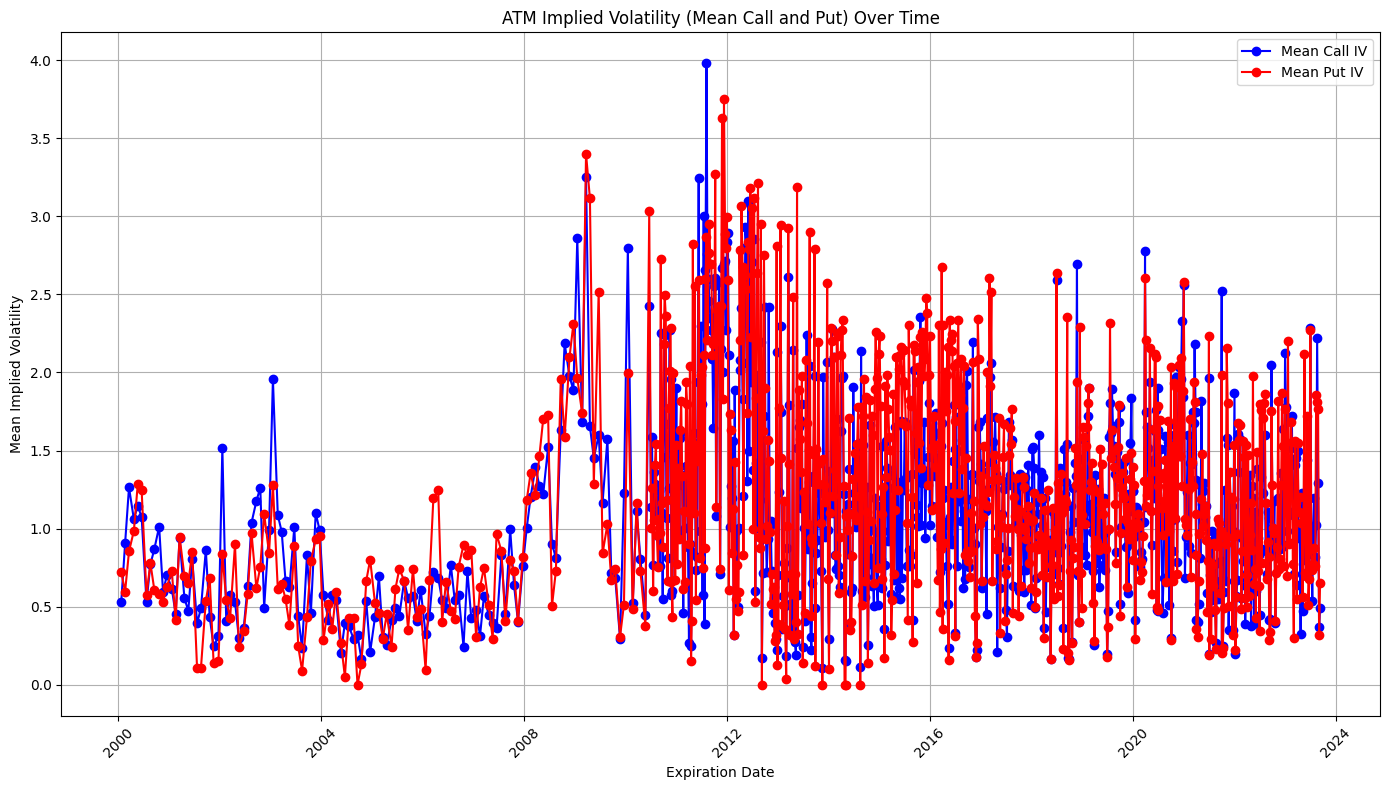

In [39]:

# Create a DataFrame to store mean IV values for calls and puts by expiration date
iv_data = []

# Step 1: Loop through each unique expiration date
unique_dates = XLF_options_data_filtered1['exdate'].unique()

for expiration in unique_dates:
    # Filter data for the specific expiration date
    daily_data = XLF_options_data_filtered1[XLF_options_data_filtered1['exdate'] == expiration].copy()  # Make a copy to avoid SettingWithCopyWarning

    # Get the current spot price for the day (assuming there's a spot_price column)
    spot_price = daily_data['price'].iloc[0]  # or find based on the specific logic for your dataset

    # Step 2: Calculate the ATM strike price for that spot price
    daily_data['atm_diff'] = abs(daily_data['strike_price'] - spot_price)

    # Find the index of the minimum difference
    atm_strike_price_index = daily_data['atm_diff'].idxmin()

    # Extract the ATM strike price using .loc to ensure it's a scalar
    atm_strike_price = daily_data.loc[atm_strike_price_index, 'strike_price'].iloc[0]  # Use iloc[0] to get the scalar

    # Ensure atm_strike_price is a single float value
    atm_strike_price = float(atm_strike_price)  # Convert to float

    # Step 3: Filter for ATM options
    atm_data = daily_data[daily_data['strike_price'] == atm_strike_price]

    # Step 4: Calculate mean implied volatility for call and put options
    call_iv_mean = atm_data[atm_data['cp_flag'] == 'C']['implied volatility'].mean()
    put_iv_mean = atm_data[atm_data['cp_flag'] == 'P']['implied volatility'].mean()

    # Append the results to the list
    iv_data.append({
        'expiration': expiration,
        'call_iv': call_iv_mean,
        'put_iv': put_iv_mean
    })

# Create a DataFrame from the list
iv_df = pd.DataFrame(iv_data)

# Convert 'expiration' to datetime
iv_df['expiration'] = pd.to_datetime(iv_df['expiration'])

# Step 5: Plot the mean implied volatilities over time
plt.figure(figsize=(14, 8))

# Plot Call IV
plt.plot(iv_df['expiration'], iv_df['call_iv'], marker='o', color='b', label='Mean Call IV')

# Plot Put IV
plt.plot(iv_df['expiration'], iv_df['put_iv'], marker='o', color='r', label='Mean Put IV')

# Add titles and labels
plt.title('ATM Implied Volatility (Mean Call and Put) Over Time')
plt.xlabel('Expiration Date')
plt.ylabel('Mean Implied Volatility')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


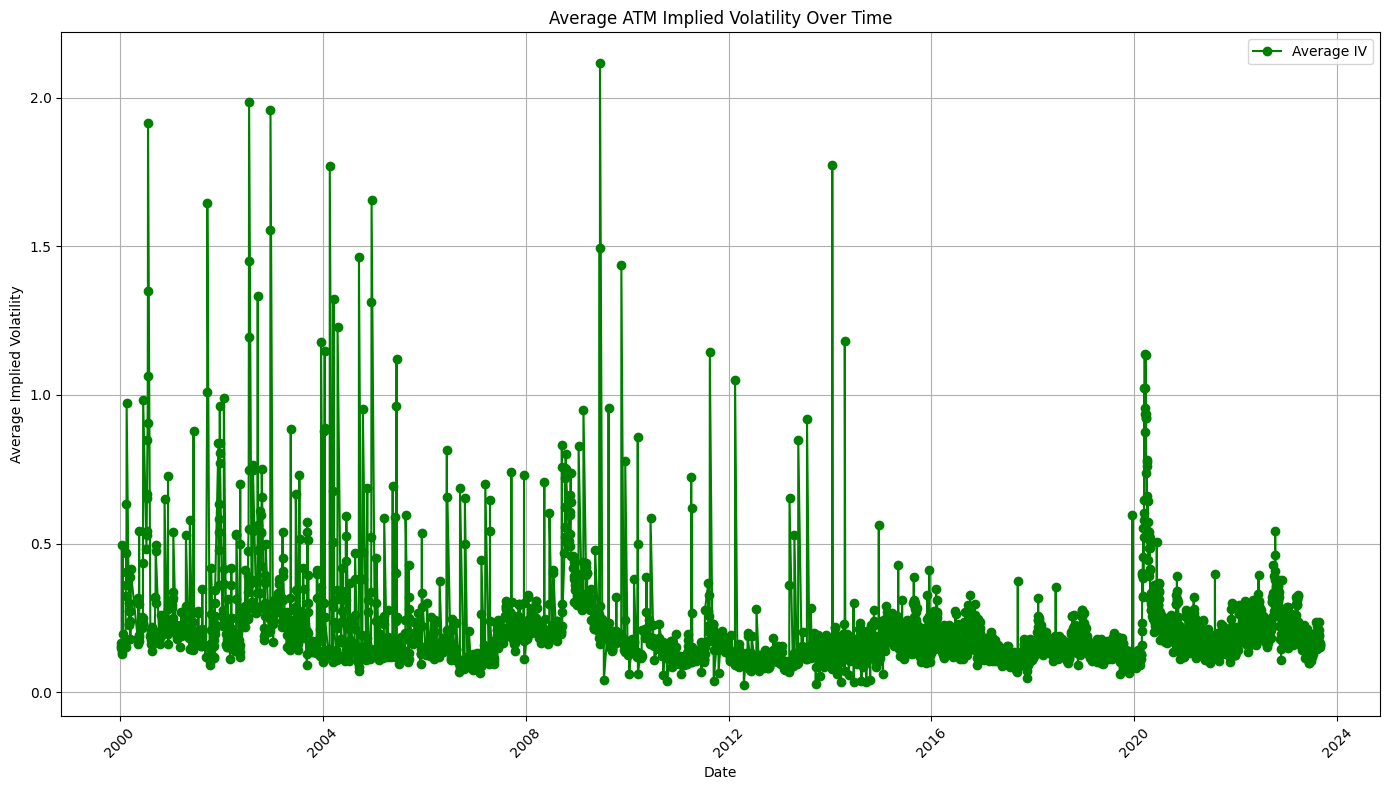

In [57]:
import matplotlib.pyplot as plt

# Step 1: Calculate the mean IV for each date grouped by 'exdate' and 'cp_flag'
mean_iv_by_date = filtered_data.groupby(['date', 'cp_flag'])['implied volatility'].mean().reset_index()

# Step 2: Pivot the DataFrame to separate Call IV and Put IV
iv_pivoted = mean_iv_by_date.pivot(index='date', columns='cp_flag', values='implied volatility')

# Step 3: Rename the columns for clarity
iv_pivoted.columns = ['Call IV', 'Put IV']

# Step 4: Calculate the average IV for each date
iv_pivoted['Average IV'] = iv_pivoted.mean(axis=1)

# Reset the index to convert it back to a DataFrame
iv_pivoted.reset_index(inplace=True)

# Step 5: Plot the average implied volatilities over time
plt.figure(figsize=(14, 8))

# Plot Average IV
plt.plot(iv_pivoted['date'], iv_pivoted['Average IV'], marker='o', color='g', label='Average IV')

# Add titles and labels
plt.title('Average ATM Implied Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Average Implied Volatility')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()



In [58]:
iv_pivoted.to_csv('average_iv_by_date.csv', index=False)